# Experiment No 7

**Aim:** To build Bagging, Boosting, and Stacking ensemble classification models on the Spambase dataset and evaluate their performance using appropriate metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    BaggingClassifier, RandomForestClassifier,
    AdaBoostClassifier, GradientBoostingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

spambase = fetch_ucirepo(id=94)
df = pd.concat([spambase.data.features, spambase.data.targets], axis=1)
display(df.head(3))

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1


### Preprocessing

In [2]:
X_data = df.drop(columns=['Class'])
y_data = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42, stratify=y_data
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

### Bagging – BaggingClassifier & Random Forest

In [3]:
bag = RandomForestClassifier(n_estimators=100, random_state=42)
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)
y_prob_bag = bag.predict_proba(X_test)[:, 1]

metrics_bag = pd.DataFrame({
    'Accuracy':  [accuracy_score(y_test, y_pred_bag)],
    'Precision': [precision_score(y_test, y_pred_bag)],
    'Recall':    [recall_score(y_test, y_pred_bag)],
    'F1-Score':  [f1_score(y_test, y_pred_bag)],
    'ROC-AUC':   [roc_auc_score(y_test, y_prob_bag)]
}).round(4)
display(metrics_bag)
print(classification_report(y_test, y_pred_bag, target_names=['Not Spam', 'Spam']))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,0.9446,0.9483,0.9091,0.9283,0.9834


              precision    recall  f1-score   support

    Not Spam       0.94      0.97      0.95       558
        Spam       0.95      0.91      0.93       363

    accuracy                           0.94       921
   macro avg       0.95      0.94      0.94       921
weighted avg       0.94      0.94      0.94       921



### Confusion Matrix, ROC Curve & Feature Importances – Random Forest

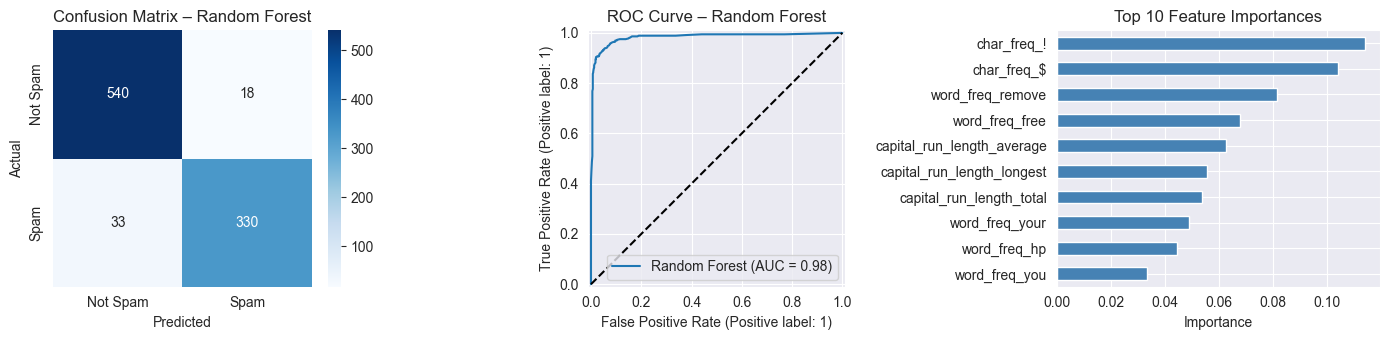

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

sns.heatmap(confusion_matrix(y_test, y_pred_bag), annot=True, fmt='d',
            cmap='Blues', ax=axes[0],
            xticklabels=['Not Spam','Spam'], yticklabels=['Not Spam','Spam'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix – Random Forest')

RocCurveDisplay.from_predictions(y_test, y_prob_bag, ax=axes[1], name='Random Forest')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('ROC Curve – Random Forest')

importances = pd.Series(bag.feature_importances_, index=X_data.columns).nlargest(10).sort_values()
importances.plot(kind='barh', color='steelblue', ax=axes[2])
axes[2].set_xlabel('Importance')
axes[2].set_title('Top 10 Feature Importances')

plt.tight_layout(); plt.show()

### Boosting – AdaBoost & Gradient Boosting

In [5]:
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)
y_prob_ada = ada.predict_proba(X_test)[:, 1]

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

metrics_boost = pd.DataFrame({
    'Model':     ['AdaBoost', 'Gradient Boosting'],
    'Accuracy':  [accuracy_score(y_test, y_pred_ada),  accuracy_score(y_test, y_pred_gb)],
    'Precision': [precision_score(y_test, y_pred_ada), precision_score(y_test, y_pred_gb)],
    'Recall':    [recall_score(y_test, y_pred_ada),    recall_score(y_test, y_pred_gb)],
    'F1-Score':  [f1_score(y_test, y_pred_ada),        f1_score(y_test, y_pred_gb)],
    'ROC-AUC':   [roc_auc_score(y_test, y_prob_ada),   roc_auc_score(y_test, y_prob_gb)]
}).round(4)
display(metrics_boost)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,AdaBoost,0.9273,0.9253,0.8871,0.9058,0.9778
1,Gradient Boosting,0.9392,0.9373,0.9063,0.9216,0.9826


### Confusion Matrices & ROC Curves – Boosting

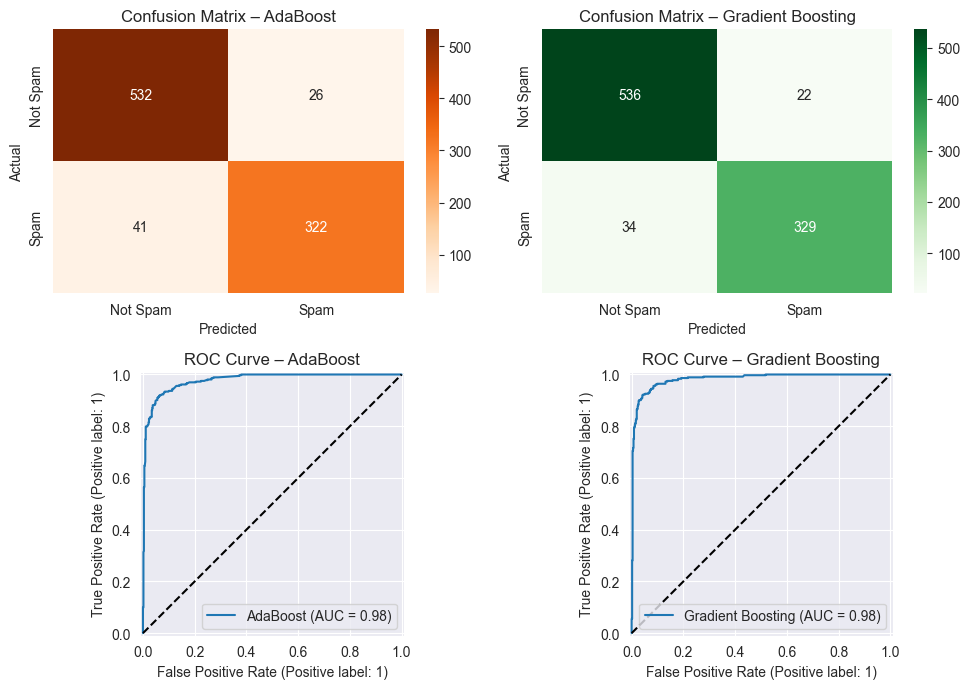

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for ax, cm, title, cmap in zip(
    [axes[0,0], axes[0,1]],
    [confusion_matrix(y_test, y_pred_ada), confusion_matrix(y_test, y_pred_gb)],
    ['Confusion Matrix – AdaBoost', 'Confusion Matrix – Gradient Boosting'],
    ['Oranges', 'Greens']
):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Not Spam','Spam'], yticklabels=['Not Spam','Spam'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title(title)

RocCurveDisplay.from_predictions(y_test, y_prob_ada, ax=axes[1,0], name='AdaBoost')
axes[1,0].plot([0,1],[0,1],'k--'); axes[1,0].set_title('ROC Curve – AdaBoost')

RocCurveDisplay.from_predictions(y_test, y_prob_gb, ax=axes[1,1], name='Gradient Boosting')
axes[1,1].plot([0,1],[0,1],'k--'); axes[1,1].set_title('ROC Curve – Gradient Boosting')

plt.tight_layout(); plt.show()

### Stacking

In [7]:
base_learners = [
    ('dt',  DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('nb',  GaussianNB())
]
meta_learner = LogisticRegression(max_iter=1000, random_state=42)

stack = StackingClassifier(estimators=base_learners, final_estimator=meta_learner, cv=5)
stack.fit(X_train_scaled, y_train)
y_pred_stack = stack.predict(X_test_scaled)
y_prob_stack = stack.predict_proba(X_test_scaled)[:, 1]

metrics_stack = pd.DataFrame({
    'Accuracy':  [accuracy_score(y_test, y_pred_stack)],
    'Precision': [precision_score(y_test, y_pred_stack)],
    'Recall':    [recall_score(y_test, y_pred_stack)],
    'F1-Score':  [f1_score(y_test, y_pred_stack)],
    'ROC-AUC':   [roc_auc_score(y_test, y_prob_stack)]
}).round(4)
display(metrics_stack)
print(classification_report(y_test, y_pred_stack, target_names=['Not Spam', 'Spam']))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,0.9229,0.9078,0.8953,0.9015,0.9804


              precision    recall  f1-score   support

    Not Spam       0.93      0.94      0.94       558
        Spam       0.91      0.90      0.90       363

    accuracy                           0.92       921
   macro avg       0.92      0.92      0.92       921
weighted avg       0.92      0.92      0.92       921



### Confusion Matrix & ROC Curve – Stacking

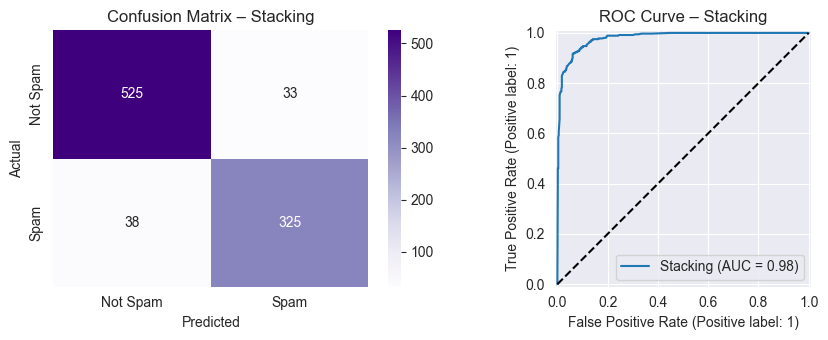

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

sns.heatmap(confusion_matrix(y_test, y_pred_stack), annot=True, fmt='d',
            cmap='Purples', ax=axes[0],
            xticklabels=['Not Spam','Spam'], yticklabels=['Not Spam','Spam'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix – Stacking')

RocCurveDisplay.from_predictions(y_test, y_prob_stack, ax=axes[1], name='Stacking')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('ROC Curve – Stacking')

plt.tight_layout(); plt.show()

## Conclusion

Ensemble methods consistently outperform single classifiers on Spambase. Bagging (Random Forest) reduces variance, Boosting (AdaBoost, Gradient Boosting) reduces bias by sequentially correcting errors, and Stacking leverages diverse base learners with a meta-learner to further improve predictions.